# HEART DISEASE PREDICTION

This project predicts the risk of heart disease using machine learning algorithms. It analyzes medical data to assist in early diagnosis and preventive care.

# Importing the Dependencies

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy.stats import ttest_ind

# Data Collection and Processing
For this project, heart disease data was collected from publicly available datasets such as the UCI Heart Disease Dataset. The dataset includes key medical attributes like age, sex, chest pain type, blood pressure, cholesterol, fasting blood sugar, ECG results, heart rate, and others.

Processing steps included:

Data Cleaning: Handling missing values and removing duplicates.

Data Encoding: Converting categorical variables into numerical format.

Feature Scaling: Normalizing numerical features for better model performance.

Feature Selection: Choosing the most relevant features to improve accuracy and reduce overfitting.

In [35]:
df = pd.read_csv('heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [36]:
# print first 5 rows of the dataset
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [37]:
# print last 5 rows of the dataset
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [6]:
# number of rows and columns in the dataset
df.shape

(1025, 14)

In [7]:
# getting some info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
# checking for missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(723)

In [16]:
df.drop_duplicates()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


In [9]:
# statistical measures about the data
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
df.rename(columns={'cp':'Chest_pain','trestbps':'Resting_Blood_Pressure','fbs':'Fasting_blood_Sugar','thalach':'Max_HeartR_Achieve'},inplace=True)
df

,age,sex,Chest_pain,Resting_Blood_Pressure,chol,Fasting_blood_Sugar,restecg,Max_HeartR_Achieve,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [6]:
#Correlation matrix
df.corr()

,age,sex,Chest_pain,Resting_Blood_Pressure,chol,Fasting_blood_Sugar,restecg,Max_HeartR_Achieve,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
Chest_pain,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
Resting_Blood_Pressure,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
Fasting_blood_Sugar,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
Max_HeartR_Achieve,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


In [7]:
# checking the distribution of Target Variable
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

C:\Users\avinash singh\AppData\Local\Temp\ipykernel_10908\748071559.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= 'target', data=df, palette='RdBu_r')


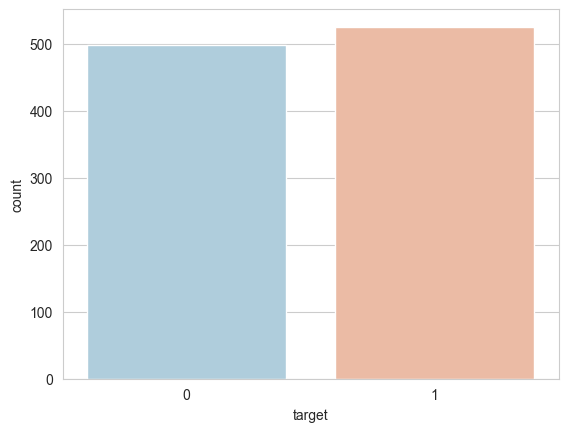

In [9]:
sns.set_style('whitegrid')
sns.countplot(x= 'target', data=df, palette='RdBu_r')
plt.show()

EDA(Exploratory Data Analysis)

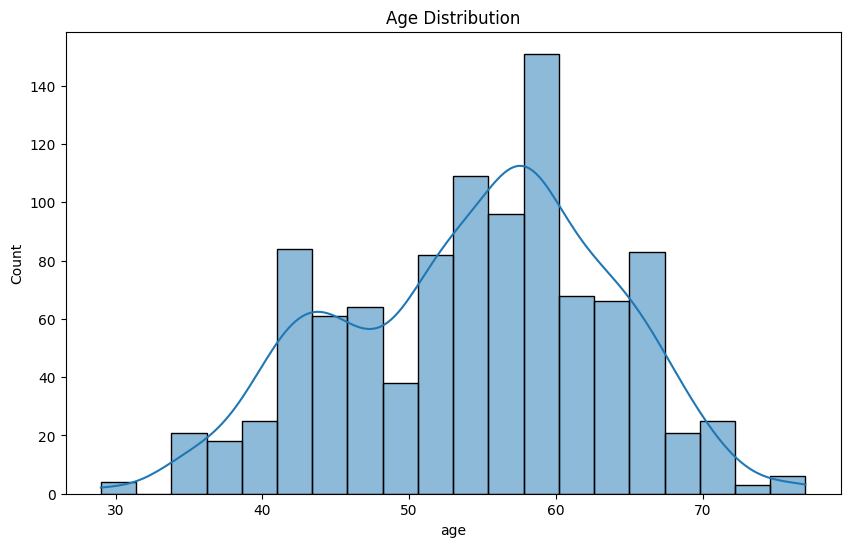

In [12]:
plt.figure(figsize = (10,6))
sns.histplot(df['age'],bins = 20 , kde = True)
plt.title("Age Distribution")
plt.show()

Text(1, 720, 'Male')

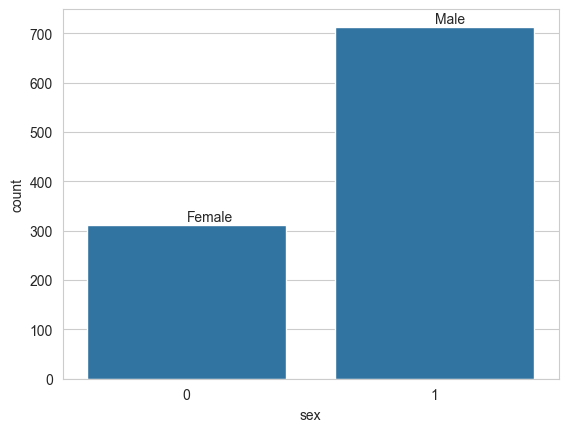

In [47]:
#Gender distribution
df['sex'].value_counts()
sns.countplot(x='sex',data = df) 
plt.text(0,320,'Female')
plt.text(1,720,'Male')

<Axes: xlabel='Chest_pain', ylabel='count'>

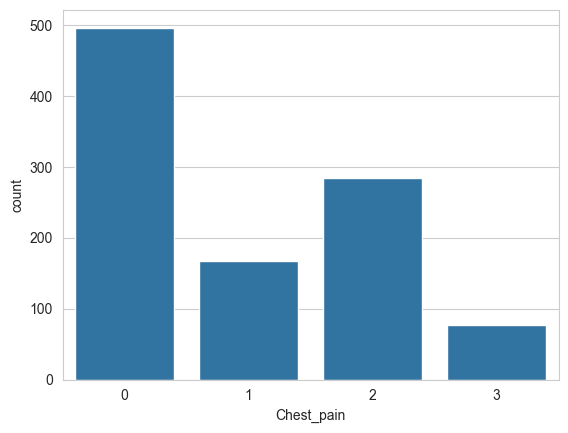

In [12]:
#Types of chest pain
df['Chest_pain'].unique()
df['Chest_pain'].value_counts()
sns.countplot(x = 'Chest_pain',data = df)      #0 = Typical angina, 1 = Atypical angina, 2 = Non-anginal pain, 3 = Asymptomatic

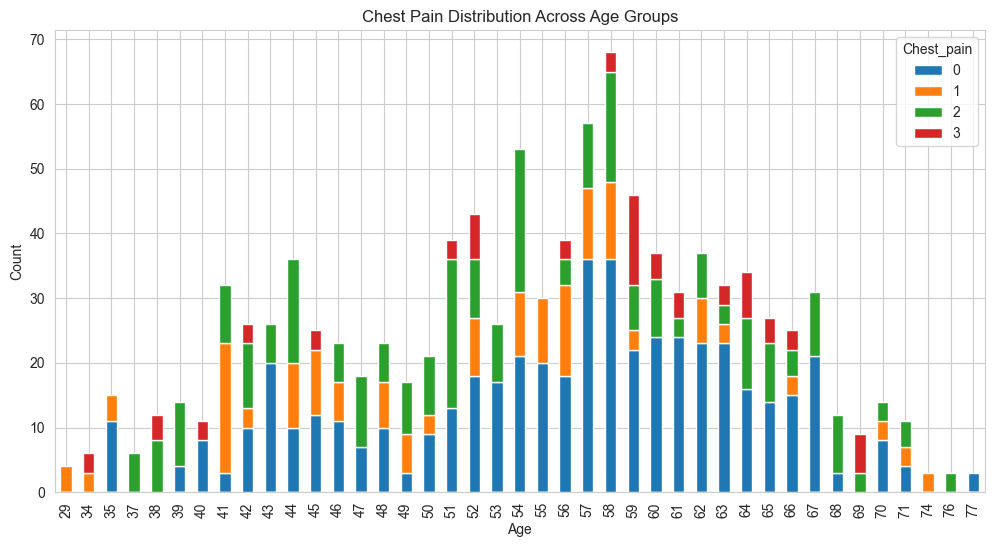

In [14]:
#Distribution of chest pain types across age groups
df.groupby('age')['Chest_pain'].value_counts().unstack().plot( kind='bar', stacked=True, figsize=(12,6))
plt.title("Chest Pain Distribution Across Age Groups")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

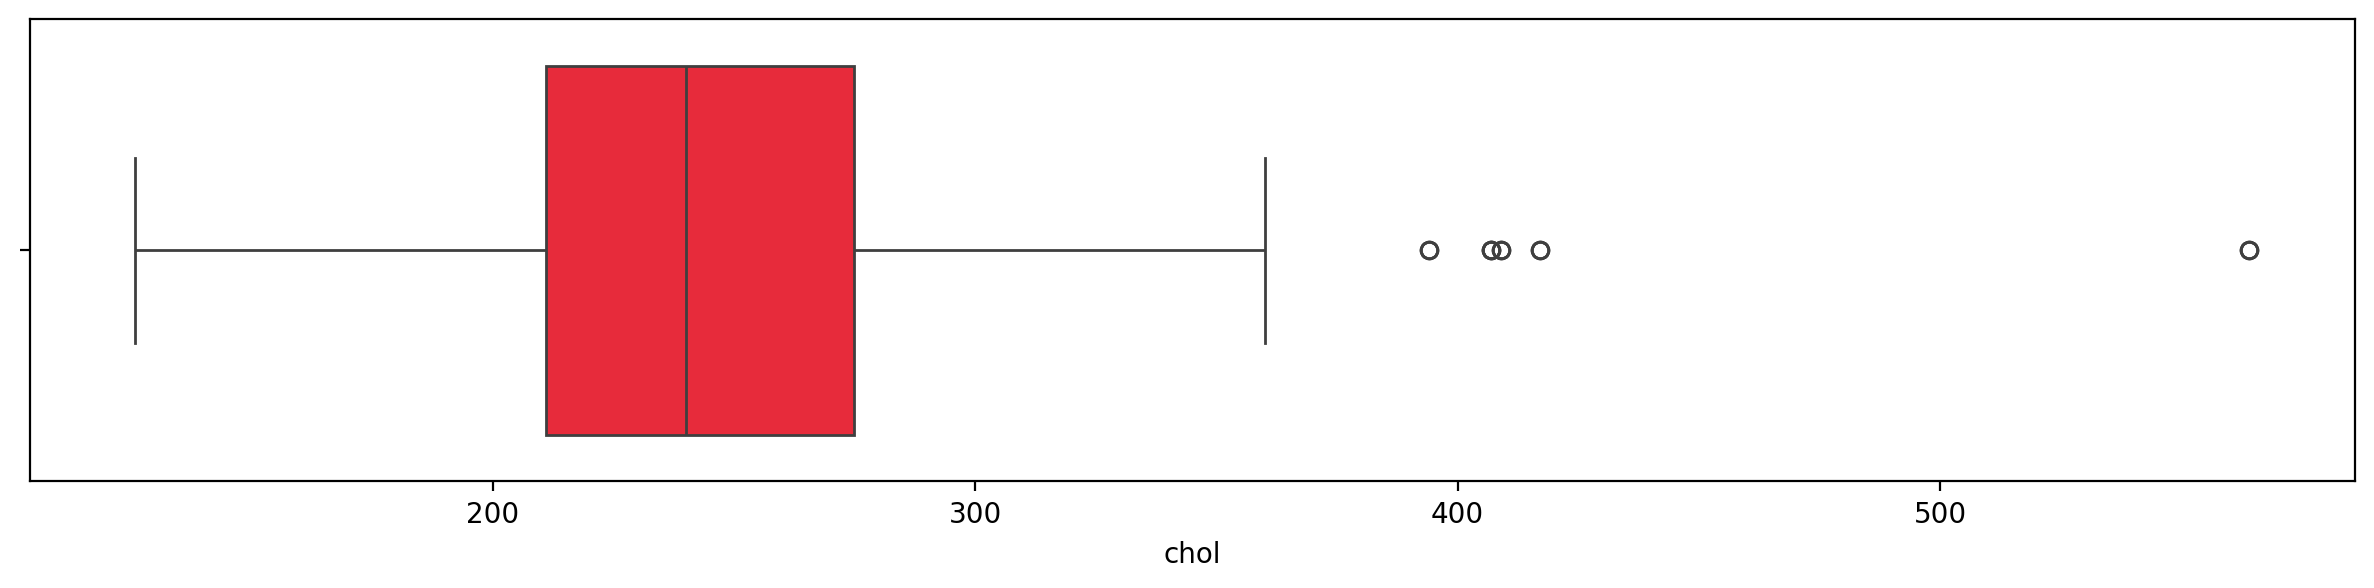

In [42]:
fig = plt.figure(figsize = [15,3], dpi=200)
sns.boxplot(x = 'chol', data = df, boxprops = dict(facecolor = "#E72B3B"))
plt.show()

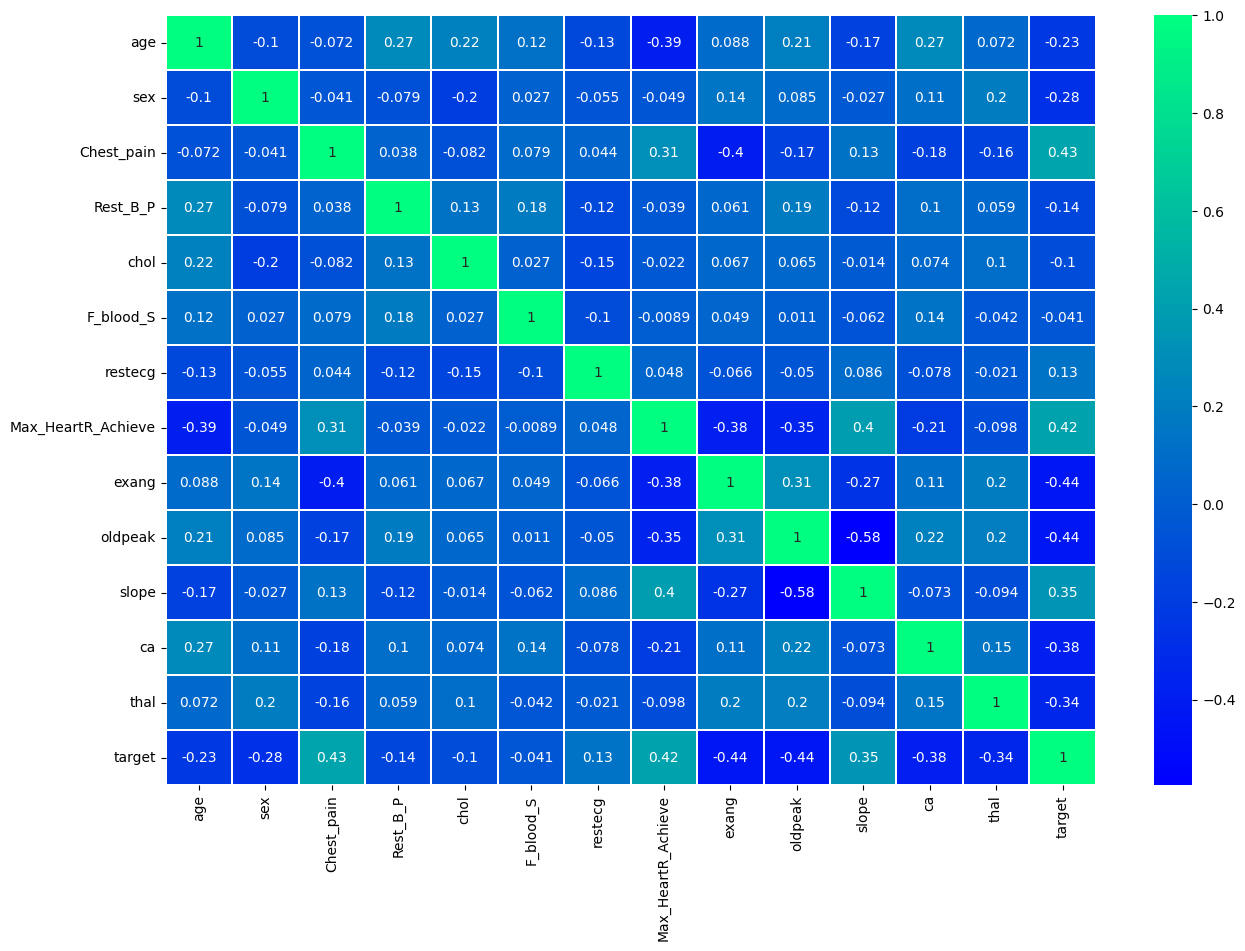

In [43]:
#Create a heatmap taking correlation matrix
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), linewidth=.01, annot=True, cmap="winter")
plt.show()

Text(0.5, 1.0, 'Scatter plot Between Age and cholestrol')

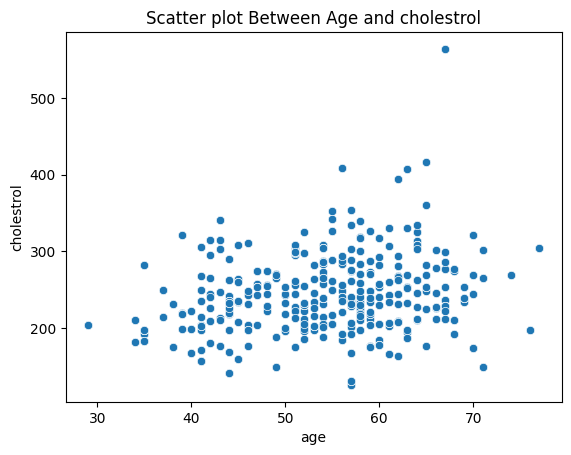

In [45]:
sns.scatterplot(x='age',y='chol',data=df)
plt.ylabel('cholestrol')
plt.title("Scatter plot Between Age and cholestrol")

Patients with Heart Disease:
              age         sex          cp    trestbps        chol         fbs  \
count  526.000000  526.000000  526.000000  526.000000  526.000000  526.000000   
mean    52.408745    0.570342    1.378327  129.245247  240.979087    0.134981   
std      9.631804    0.495498    0.945881   16.112188   53.010345    0.342029   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     44.000000    0.000000    1.000000  120.000000  208.000000    0.000000   
50%     52.000000    1.000000    2.000000  130.000000  234.000000    0.000000   
75%     59.000000    1.000000    2.000000  140.000000  265.750000    0.000000   
max     76.000000    1.000000    3.000000  180.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  526.000000  526.000000  526.000000  526.000000  526.000000  526.000000   
mean     0.598859  158.585551    0.134981    0.569962    1.593156    0.370722  

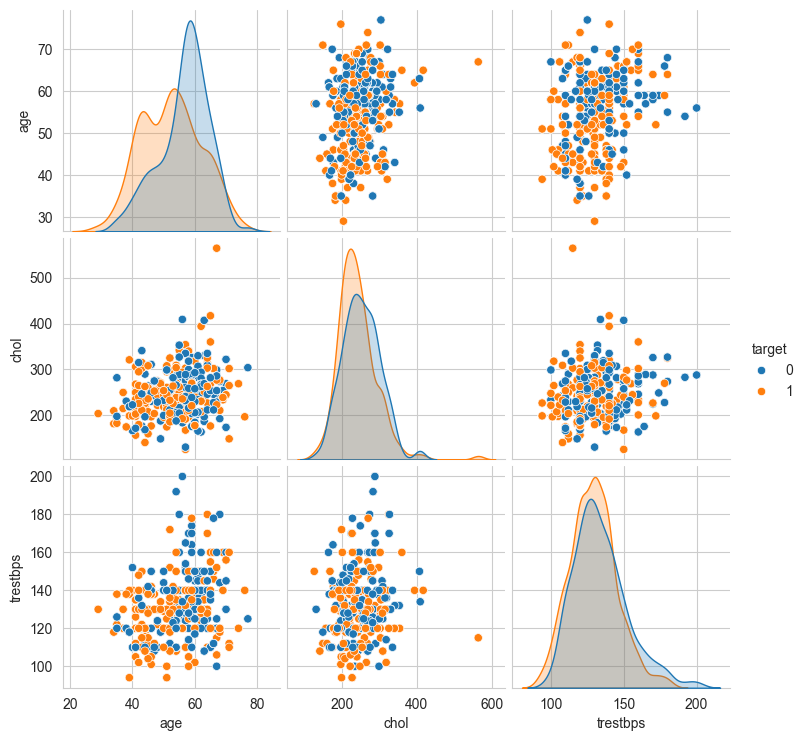

In [38]:
# Summary statistics for patients with heart disease (target = 1)
print("Patients with Heart Disease:")
print(df[df['target'] == 1].describe())

# Summary statistics for patients without heart disease (target = 0)
print("\nPatients without Heart Disease:")
print(df[df['target'] == 0].describe())

# Visualization: pairplot for selected variables
sns.pairplot(df, hue='target', vars=['age', 'chol', 'trestbps'])
plt.show()


trtbps : resting blood pressure (in mm Hg)

#Choose X and Y
x=df.iloc[:,:-1]
x

In [10]:
y=df.iloc[:,-1]
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

In [11]:
#split dataset into training and testing data
from sklearn.model_selection import train_test_split
y_train, y_test, y_train, y_test = train_test_split(x,y, test_size=0.25, random_state=42)
y_test

527    1
359    1
447    0
31     1
621    0
      ..
940    0
787    0
926    0
249    1
552    0
Name: target, Length: 257, dtype: int64

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
print(x.shape, x_train.shape, x_test.shape)

(1025, 13) (820, 13) (205, 13)


Model Training

Logistic Regression

In [16]:
#create a Logistic Regression Model
model = LogisticRegression()
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
#Logistic Regression Model
x= df.drop('target',axis = 1)
y = df['target']

x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size =0.2 , random_state = 42)

model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.7951219512195122
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



# Summary
This project aims to predict the risk of heart disease using machine learning models. By analyzing key health indicators such as blood pressure, cholesterol, and age, the system helps in early detection and supports medical decision-making.


# Conclusion
The Heart Disease Prediction system successfully uses machine learning techniques to analyze patient data and predict the likelihood of heart disease. This tool can support early diagnosis, improve treatment decisions, and potentially save lives through timely intervention.

Logistic Regression

Used for binary classification (e.g., presence or absence of heart disease).

Interpretable and fast.

Good baseline model.